In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")

In [9]:
columns = ["variance", "skewness", "curtosis", "entropy", "class"]

df = pd.read_csv("../data/data_banknote_authentication.txt", header=None, names=columns)

df.head()


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [10]:
df.shape

(1372, 5)

In [11]:
df.info

<bound method DataFrame.info of       variance  skewness  curtosis  entropy  class
0      3.62160   8.66610   -2.8073 -0.44699      0
1      4.54590   8.16740   -2.4586 -1.46210      0
2      3.86600  -2.63830    1.9242  0.10645      0
3      3.45660   9.52280   -4.0112 -3.59440      0
4      0.32924  -4.45520    4.5718 -0.98880      0
...        ...       ...       ...      ...    ...
1367   0.40614   1.34920   -1.4501 -0.55949      1
1368  -1.38870  -4.87730    6.4774  0.34179      1
1369  -3.75030 -13.45860   17.5932 -2.77710      1
1370  -3.56370  -8.38270   12.3930 -1.28230      1
1371  -2.54190  -0.65804    2.6842  1.19520      1

[1372 rows x 5 columns]>

In [12]:
df.isnull().sum()

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

In [13]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


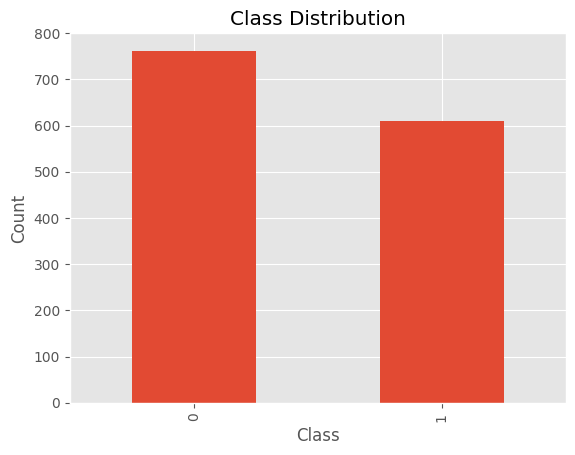

In [14]:
df["class"].value_counts().plot(
    kind = "bar",
    title = "Class Distribution"
)
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

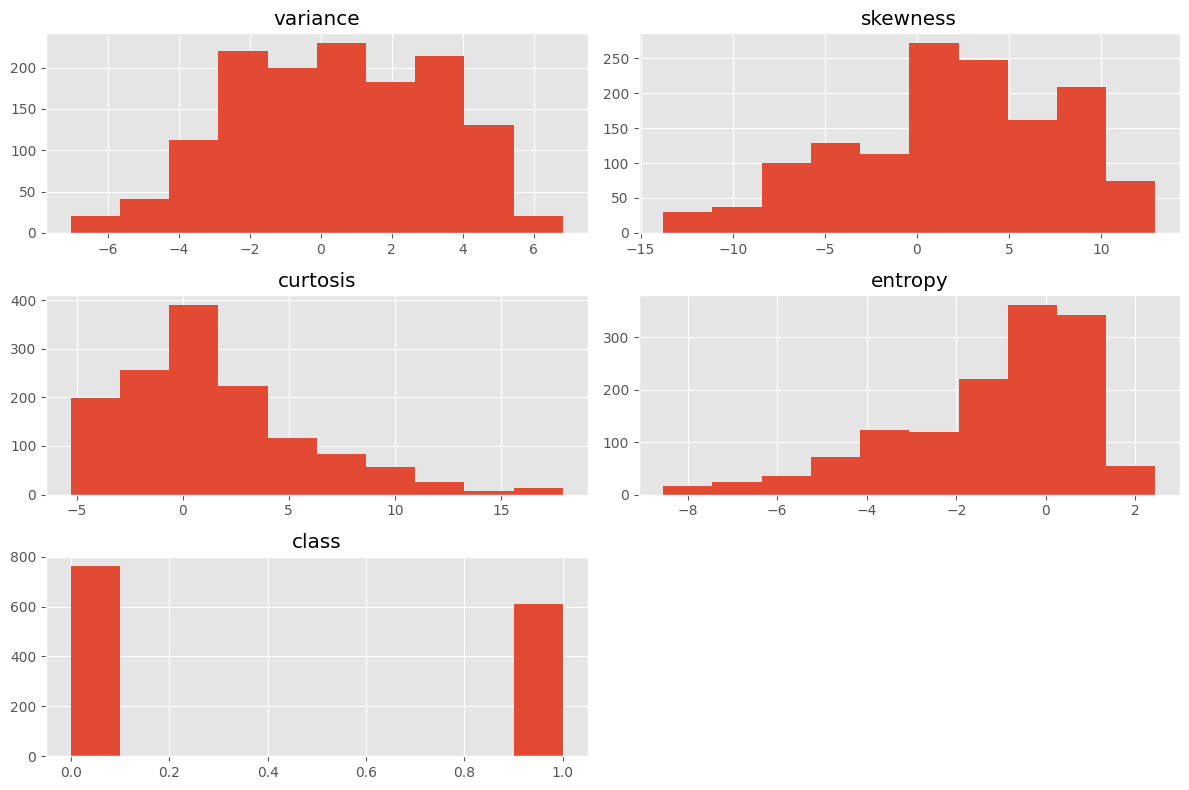

<Figure size 640x480 with 0 Axes>

In [20]:
df.hist(figsize=(12,8))

plt.tight_layout()

plt.show()

plt.savefig("../outputs/plots/histograms.png")

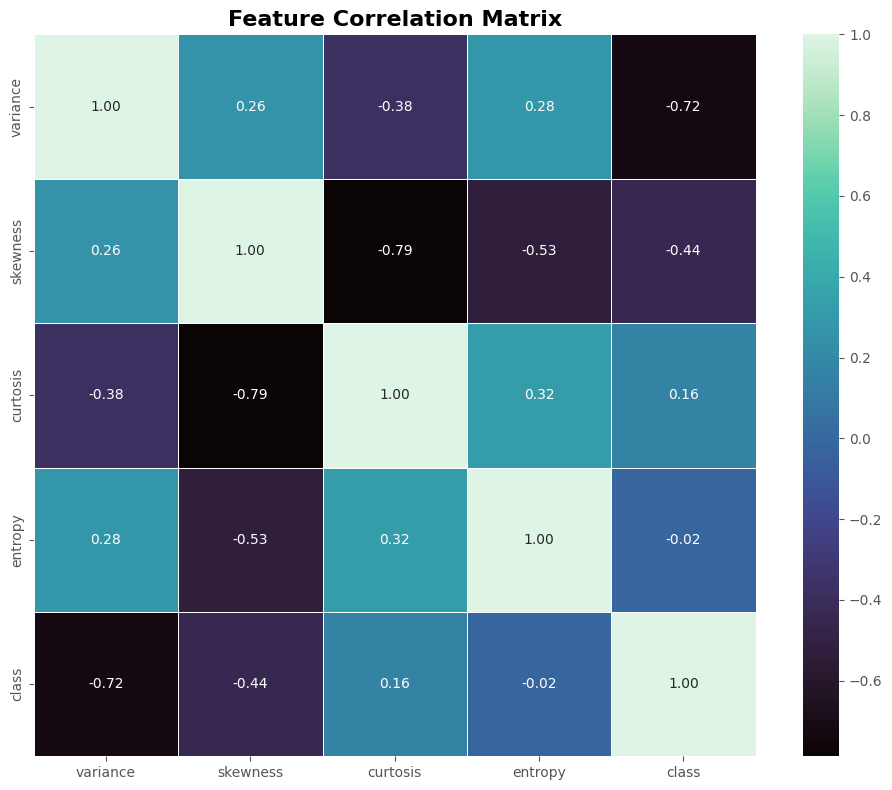

In [27]:
# Correlation map of features

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="mako",
    linewidths=0.5,
    linecolor="white",
    square=True,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix", fontsize=16, weight="bold")
plt.tight_layout()
plt.savefig("../outputs/plots/feature_correlation_map.png", dpi=600)
plt.show()

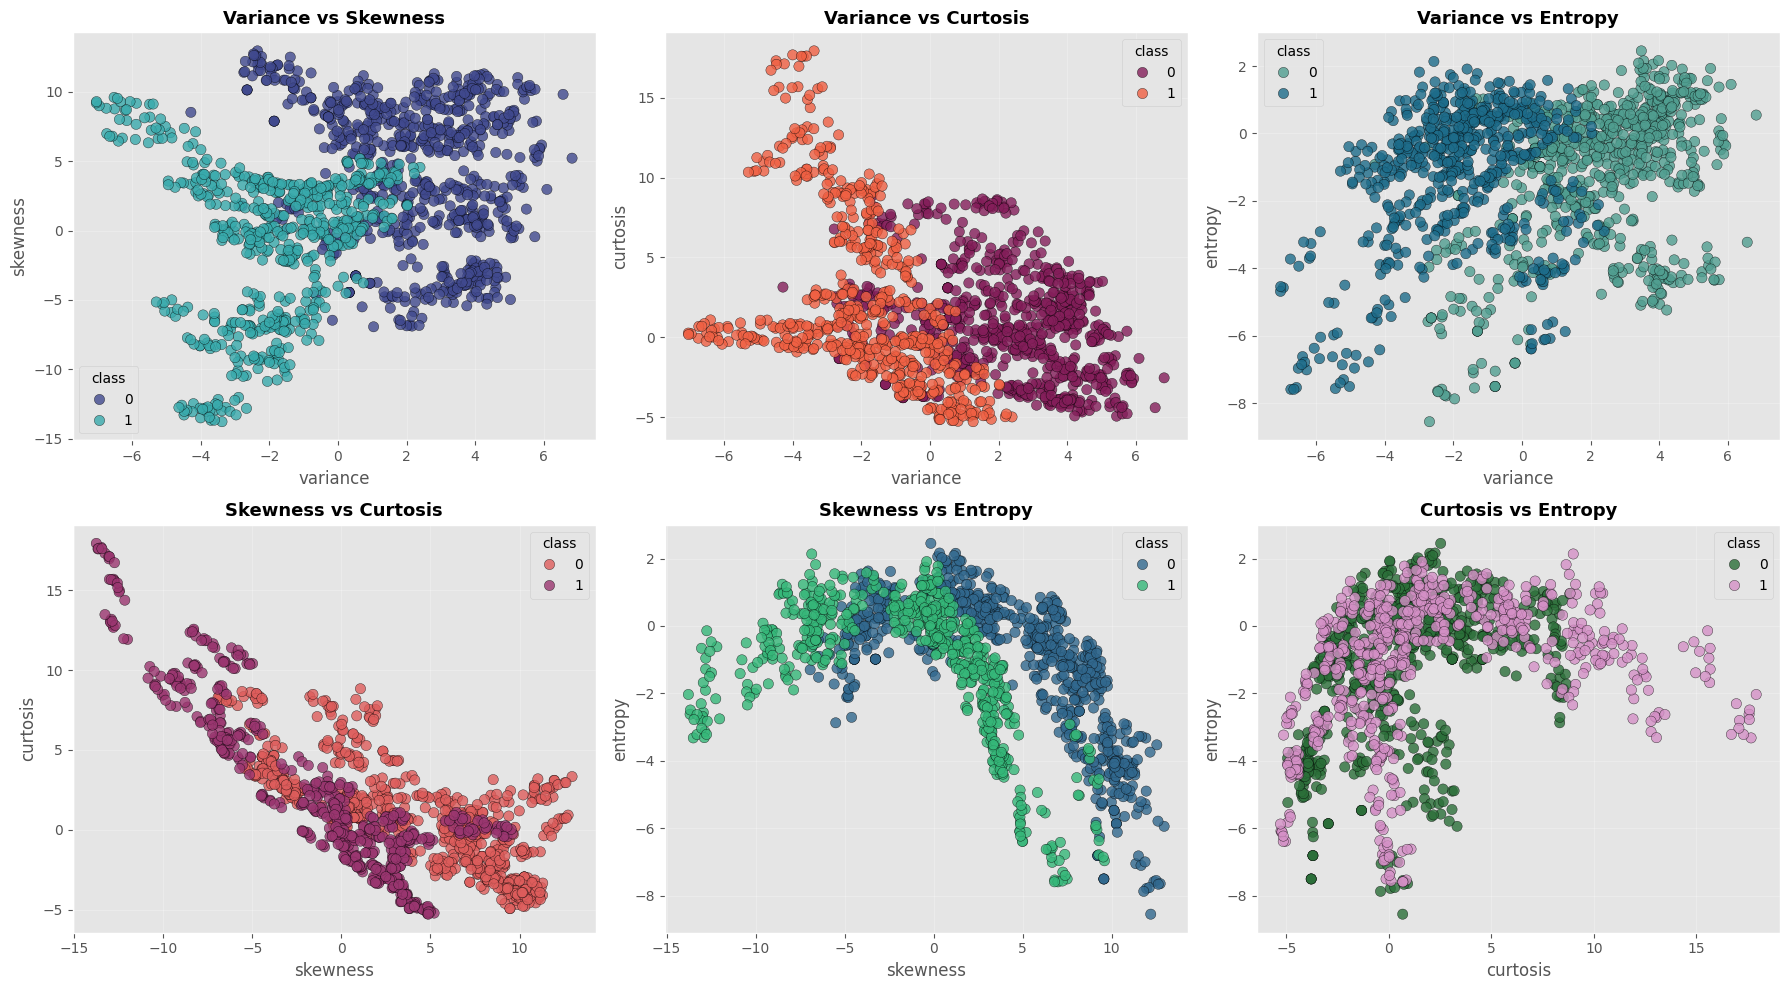

In [25]:
"""
plt.figure(figsize=(10,8))

sns.scatterplot(
    data = df,
    x = "variance",
    y = "skewness",
    hue = "class",
    palette = "plasma",
)

plt.title("Variance vs Skewness")
plt.savefig("../outputs/plots/scatter.png")

plt.show()
"""

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

features = ["variance", "skewness", "curtosis", "entropy"]

# 6 unique feature pairs
pairs = list(combinations(features, 2))

# Nice palettes
palettes = [
    "mako",      # deep blue
    "rocket",    # dark red
    "crest",     # teal
    "flare",     # orange/pink
    "viridis",   # green/blue
    "cubehelix"  # purple
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (x, y), palette in zip(axes.flat, pairs, palettes):
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue="class",
        palette=palette,
        s=55,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.3,
        ax=ax
    )

    ax.set_title(f"{x.title()} vs {y.title()}", fontsize=13, weight="bold")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("../outputs/plots/all_scatterplots.png", dpi=300)
plt.show()

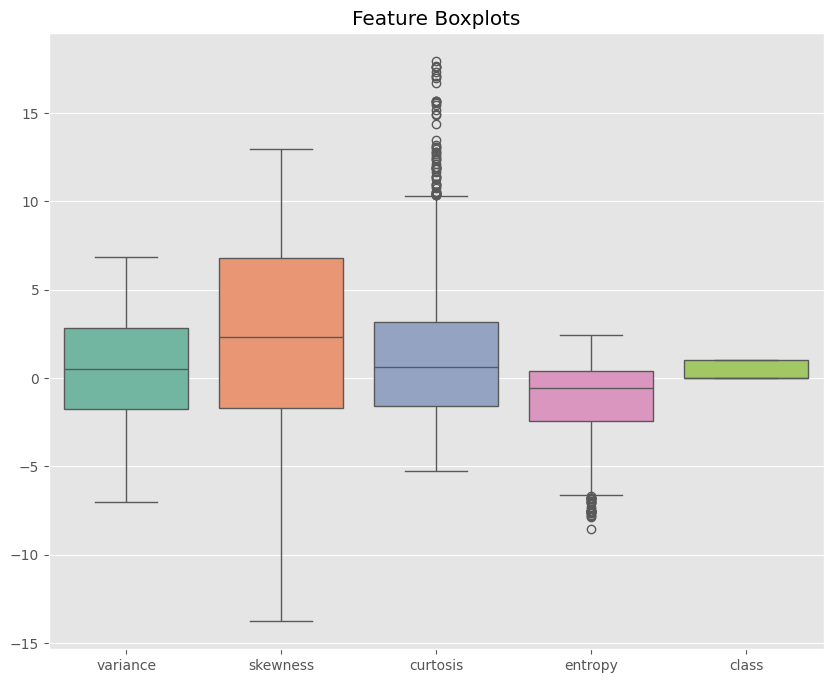

In [24]:
plt.figure(figsize=(10,8))

sns.boxplot(data = df, palette = "Set2")

plt.title("Feature Boxplots")
plt.savefig("../outputs/plots/boxplots.png")
plt.show()